In [23]:
import pandas as pd
import numpy as np
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt


In [35]:
DATA_DIR = Path(".")
BEGINNING_DATE = pd.to_datetime("2023-01-01")

files = {
    "Arges": DATA_DIR / "river_arges_data.csv",
    "Vedea": DATA_DIR / "river_vedea_data.csv",
    # "Dambovita": DATA_DIR / "river_dambovita_data.csv",
}

In [36]:

def strip_accents(text):
    if pd.isna(text):
        return np.nan
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    return "".join(c for c in text if not unicodedata.combining(c))

def clean_text(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    text = " ".join(text.split())
    return text

def to_float_ro(x):
    """Transformă valori de tip '27,0', '1,34', '-' în float."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ["", "-", "nan", "NaN", "None"]:
        return np.nan
    x = x.replace(",", ".")
    try:
        return float(x)
    except ValueError:
        return np.nan

def standardize_station(station):
    s = clean_text(station)
    s_ascii = strip_accents(s).lower().replace(" ", "")

    if "maluspart" in s_ascii or "mauspart" in s_ascii:
        return "Malu Spart"
    if "alexandria" in s_ascii:
        return "Alexandria"
    if "malucuflor" in s_ascii or "maucuflor" in s_ascii:
        return "Malu cu Flori"
    if "campeni" in s_ascii or "camperi" in s_ascii:
        return "Campeni"

    return s

dfs = []

for river_name, path in files.items():
    df = pd.read_csv(path)

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["statia_matched"] = df["statia_hidrometrica"].apply(standardize_station)

    numeric_cols = [
        "CA_cm", "CI_cm", "CP_cm",
        "Qmed_apr_m3_s",
        "diag_H_cm", "diag_Q_m3_s", "diag_dH_cm",
        "prog_H_cm", "prog_Q_m3_s", "prog_dH_cm",
    ]

    for col in numeric_cols:
        df[col] = df[col].apply(to_float_ro)

    # Shift prognoza columns one day earlier
    prog_df = df[["date", "raul_matched", "prog_H_cm", "prog_Q_m3_s"]].copy()
    prog_df["date"] = prog_df["date"] + pd.Timedelta(days=1)
    df = df.drop(columns=["prog_H_cm", "prog_Q_m3_s"]).merge(prog_df, on=["date", "raul_matched"])

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

main_data = data
[
    (
        (data["raul_matched"] == "arges") &
        (data["statia_matched"] == "Malu Spart")
    ) |
    (
        (data["raul_matched"] == "vedea") &
        (data["statia_matched"] == "Alexandria")
    )
].copy()
main_data = main_data[main_data["date"] >= BEGINNING_DATE].copy()

# Indicatori derivați
main_data["pct_CA_diag"] = main_data["diag_H_cm"] / main_data["CA_cm"] * 100
main_data["pct_CI_diag"] = main_data["diag_H_cm"] / main_data["CI_cm"] * 100
main_data["pct_CP_diag"] = main_data["diag_H_cm"] / main_data["CP_cm"] * 100

main_data["Q_ratio_diag"] = main_data["diag_Q_m3_s"] / main_data["Qmed_apr_m3_s"]
main_data["Q_ratio_prog"] = main_data["prog_Q_m3_s"] / main_data["Qmed_apr_m3_s"]

# Clasificare simplă a nivelului de risc
def risk_class(pct_ca):
    if pd.isna(pct_ca):
        return np.nan
    if pct_ca >= 100:
        return "depășire CA"
    if pct_ca >= 80:
        return "foarte ridicat"
    if pct_ca >= 50:
        return "ridicat"
    return "normal"

main_data["risk_class"] = main_data["pct_CA_diag"].apply(risk_class)

In [80]:
cota_summary = (
    main_data
    .groupby(["raul_matched", (main_data["date"] < "2024-02-24").replace({True: "before_2024_02_24", False: "after_2024_02_24"}).rename("period")])
    .agg(
        # start_date=("date", "min"),
        # end_date=("date", "max"),
        n_obs=("date", "count"),
        CA_max=("CA_cm", "max"),
        CI_max=("CI_cm", "max"),
        CP_max=("CP_cm", "max"),
    )
    .reset_index()
)

cota_summary

,raul_matched,period,n_obs,CA_max,CI_max,CP_max
0,arges,after_2024_02_24,677,510.0,600.0,750.0
1,arges,before_2024_02_24,331,210.0,240.0,300.0
2,vedea,after_2024_02_24,677,510.0,600.0,750.0
3,vedea,before_2024_02_24,331,380.0,500.0,650.0


In [54]:
overall_summary = (
    main_data
    .groupby(["raul_matched", "statia_matched"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_obs=("date", "count"),
        H_max=("diag_H_cm", "max"),
        Q_max=("diag_Q_m3_s", "max"),
        pct_CA_max=("pct_CA_diag", "max"),
        Q_ratio_max=("Q_ratio_diag", "max"),
    )
    .reset_index()
)

overall_summary

,raul_matched,statia_matched,start_date,end_date,n_obs,H_max,Q_max,pct_CA_max,Q_ratio_max
0,arges,Malu Spart,2023-01-01,2026-04-19,1008,456.0,585.0,89.411765,22.674419
1,vedea,Alexandria,2023-01-01,2026-04-19,1008,300.0,135.0,78.947368,10.746479


In [49]:
monthly_summary = (
    main_data
    .groupby(["raul_matched", pd.Grouper(key="date", freq="ME")])
    .agg(
        start_date=("date", "min"),
        # end_date=("date", "max"),
        n_obs=("date", "count"),
        H_max=("diag_H_cm", "max"),
        Q_max=("diag_Q_m3_s", "max"),
        Q_std=("diag_Q_m3_s", "std"),
        # CA=("CA_cm", "median"),
        # CI=("CI_cm", "median"),
        # CP=("CP_cm", "median"),
        pct_CA_max=("pct_CA_diag", "max"),
        Q_ratio_max=("Q_ratio_diag", "max"),
    )
    .reset_index()
)

monthly_summary.set_index(["start_date", "raul_matched"]).unstack("raul_matched").swaplevel(axis=1).sort_index(axis=1, level=0)

raul_matched  arges                                                  \
              H_max  Q_max Q_ratio_max       Q_std       date n_obs   
start_date                                                            
2023-01-01    -81.0  109.0    4.954545   23.531365 2023-01-31    17   
2023-02-01    122.0   59.8    2.481328   13.900570 2023-02-28    19   
2023-03-02    128.0   56.4    1.597734   10.813280 2023-03-31    28   
2023-04-01    123.0   71.0    1.256637   18.408560 2023-04-30    27   
2023-05-02    114.0  112.0    1.365854   28.978010 2023-05-31    30   
2023-06-01    -74.0  112.0    1.627907   21.595429 2023-06-30    28   
2023-07-01   -121.0   61.1    1.363839   13.036579 2023-07-31    26   
2023-08-02     95.0   34.3    1.162712   10.321025 2023-08-31    28   
2023-09-01    180.0   33.5    1.522727    3.783117 2023-09-30    28   
2023-10-01   -175.0   20.5    0.899123    0.775107 2023-10-31    23   
2023-11-03    181.0   22.1    0.887550    5.916792 2023-11-30    20   
2023-12-01    185.0   22.1    0.856589    3.734330 2023-12-31    21   
2024-01-03     87.0   52.6    2.390909   11.295476 2024-01-31    23   
2024-02-02    233.0  135.0    1.475410   27.373293 2024-02-29    19   
2024-03-01    122.0   21.7    0.614731    2.854926 2024-03-31    25   
2024-04-02    125.0   23.5    0.415929    1.780043 2024-04-30    26   
2024-05-04    174.0   56.7    0.691463    9.914515 2024-05-31    24   
2024-06-02    142.0   33.7    0.489826    4.570191 2024-06-30    26   
2024-07-02    136.0   30.1    0.671875    3.441163 2024-07-31    25   
2024-08-02    128.0   25.3    0.857627    2.435488 2024-08-31    25   
2024-09-02    127.0   24.7    1.122727    3.686338 2024-09-30    23   
2024-10-02    111.0   18.7    0.820175    2.796387 2024-10-31    30   
2024-11-01    110.0   18.4    0.738956    0.696287 2024-11-30    26   
2024-12-02    121.0   21.6    0.837209    1.791346 2024-12-31    20   
2025-01-01    120.0   21.2    0.963636    1.192431 2025-01-31    31   
2025-02-01    109.0   18.1    0.751037    1.179859 2025-02-28    25   
2025-03-02    111.0   16.9    0.478754    0.805191 2025-03-31    25   
2025-04-02    105.0   15.3    0.433428    2.882895 2025-04-30    23   
2025-05-02    227.0  122.0    1.487805   27.023769 2025-05-31    28   
2025-06-01    207.0   93.8    1.363372   18.027994 2025-06-30    25   
2025-07-02    152.0   36.5    0.814732    4.752234 2025-07-31    30   
2025-08-01    140.0   29.0    0.983051    3.243569 2025-08-31    26   
2025-09-01    178.0   60.2    2.736364   10.351949 2025-09-30    26   
2025-10-01    220.0  101.0    4.429825   17.698153 2025-10-31    27   
2025-11-02    266.0  171.0    6.867470   32.370591 2025-11-30    27   
2025-12-01    456.0  585.0   22.674419  138.653705 2025-12-31    27   
2026-01-01    232.0  116.0    5.272727   28.824589 2026-01-31    28   
2026-02-02    225.0  107.0    4.439834   19.969303 2026-02-28    24   
2026-03-02    171.0   53.9    1.526912    8.930681 2026-03-31    30   
2026-04-01    150.0   38.0    0.672566    7.753207 2026-04-30    19   

raul_matched             vedea                                            \
             pct_CA_max  H_max   Q_max Q_ratio_max      Q_std       date   
start_date                                                                 
2023-01-01   -38.571429  158.0   38.70    2.764286   8.930064 2023-01-31   
2023-02-01    58.095238  192.0   69.30    4.149701  14.859897 2023-02-28   
2023-03-02    60.952381  126.0   31.80    0.900850   7.295649 2023-03-31   
2023-04-01    58.571429  170.0   64.00    1.537037  15.328248 2023-04-30   
2023-05-02    54.285714  167.0   58.60    0.877551  13.867864 2023-05-31   
2023-06-01   -35.238095  122.0    2.94    0.430454   0.150661 2023-06-30   
2023-07-01   -57.619048  120.0   56.90    1.270089  10.847810 2023-07-31   
2023-08-02    45.238095  115.0   17.70    1.200000   3.423732 2023-08-31   
2023-09-01    85.714286  115.0    6.10    0.848739   0.818431 2023-09-30   
2023-10-01   -83.333333  114.0    

In [50]:
# Top episoade după apropierea de cota de atenție
top_events = (
    main_data
    .sort_values("pct_CA_diag", ascending=False)
    [[
        "date", "raul_matched", "statia_matched",
        "diag_H_cm", "diag_Q_m3_s",
        "CA_cm", "CI_cm", "CP_cm",
        "pct_CA_diag", "Q_ratio_diag", "risk_class"
    ]]
    .head(15)
)

top_events

,date,raul_matched,statia_matched,diag_H_cm,diag_Q_m3_s,CA_cm,CI_cm,CP_cm,pct_CA_diag,Q_ratio_diag,risk_class
903,2025-12-25,arges,Malu Spart,456.0,585.00,510.0,540.0,600.0,89.411765,22.674419,foarte ridicat
293,2023-12-27,arges,Malu Spart,185.0,16.50,210.0,240.0,300.0,88.095238,0.639535,foarte ridicat
270,2023-11-26,arges,Malu Spart,181.0,18.10,210.0,240.0,300.0,86.190476,0.726908,foarte ridicat
209,2023-09-08,arges,Malu Spart,180.0,8.52,210.0,240.0,300.0,85.714286,0.387273,foarte ridicat
1967,2026-02-26,vedea,Alexandria,300.0,78.00,380.0,500.0,550.0,78.947368,5.379310,ridicat
882,2025-12-02,arges,Malu Spart,390.0,433.00,510.0,540.0,600.0,76.470588,16.782946,ridicat
881,2025-12-01,arges,Malu Spart,358.0,359.00,510.0,540.0,600.0,70.196078,13.914729,ridicat
1962,2026-02-21,vedea,Alexandria,258.0,56.50,380.0,500.0,550.0,67.894737,3.896552,ridicat
1968,2026-02-27,vedea,Alexandria,250.0,53.00,380.0,500.0,550.0,65.789474,3.655172,ridicat
1045,2023-02-27,vedea,Alexandria,192.0,69.30,300.0,400.0,500.0,64.000000,4.149701,ridicat


In [84]:
# Compate performance prognoza vs diagnoza
main_data["prog_abs_error_H_cm"] = np.abs(main_data["prog_H_cm"] - main_data["diag_H_cm"])
main_data["prog_abs_error_Q_m3_s"] = np.abs(main_data["prog_Q_m3_s"] - main_data["diag_Q_m3_s"])

In [89]:
overall_error = main_data.groupby("raul_matched").agg(
    prog_H_error_mean=("prog_abs_error_H_cm", "mean"),
    prog_H_error_std=("prog_abs_error_H_cm", "std"),
    prog_Q_error_mean=("prog_abs_error_Q_m3_s", "mean"),
    prog_Q_error_std=("prog_abs_error_Q_m3_s", "std"),
)

overall_error

,prog_H_error_mean,prog_H_error_std,prog_Q_error_mean,prog_Q_error_std
raul_matched,,,,
arges,18.702381,55.687744,6.392694,21.585551
vedea,9.922619,46.909281,2.148278,10.237039


In [91]:
monthly_error = main_data.groupby(["raul_matched", pd.Grouper(key="date", freq="ME")]).agg(
    prog_H_error_mean=("prog_abs_error_H_cm", "mean"),
    prog_H_error_std=("prog_abs_error_H_cm", "std"),
    prog_Q_error_mean=("prog_abs_error_Q_m3_s", "mean"),
    prog_Q_error_std=("prog_abs_error_Q_m3_s", "std"),
).unstack("raul_matched").swaplevel(axis=1).sort_index(axis=1, level=0)

monthly_error

raul_matched             arges                                     \
             prog_H_error_mean prog_H_error_std prog_Q_error_mean   
date                                                                
2023-01-31           19.823529        58.611257          4.764706   
2023-02-28           16.157895        56.735510          2.436842   
2023-03-31           24.071429        70.370937          4.317857   
2023-04-30           24.407407        63.262736          8.451852   
2023-05-31           43.100000        83.104152         11.638333   
2023-06-30           15.214286        40.213649         10.305357   
2023-07-31           13.307692        11.888715         10.857692   
2023-08-31          111.785714       112.415024         10.761929   
2023-09-30           29.571429        93.513884          2.491429   
2023-10-31            1.913043         1.856513          0.765217   
2023-11-30           83.250000       121.824669         10.130400   
2023-12-31           86.761905       140.588372          3.165714   
2024-01-31           97.565217       120.516625         10.797130   
2024-02-29           25.421053        72.639380          8.157895   
2024-03-31            7.160000        22.152276          6.108000   
2024-04-30            2.346154         2.152994          1.407692   
2024-05-31            6.375000         6.638573          4.191667   
2024-06-30            4.115385         4.794388          2.446154   
2024-07-31            4.280000         4.392418          2.568000   
2024-08-31            4.000000         4.536886          2.316000   
2024-09-30            3.608696         4.019714          1.778261   
2024-10-31            3.033333         2.370557          1.166667   
2024-11-30            1.846154         2.053140          0.480769   
2024-12-31            1.450000         1.431782          0.410000   
2025-01-31            2.741935         2.435402          0.758065   
2025-02-28            1.880000         2.185559          0.648000   
2025-03-31            2.640000         2.497999          0.712000   
2025-04-30            1.869565         3.049655          0.892174   
2025-05-31            6.000000         6.901422          3.871429   
2025-06-30            5.480000         6.117734          4.992000   
2025-07-31            3.933333         8.245932          1.716667   
2025-08-31            4.076923         5.051123          2.288462   
2025-09-30            8.192308        12.441927          5.188462   
2025-10-31           15.592593        17.200759         13.425926   
2025-11-30           15.481481        19.315937         13.566667   
2025-12-31           32.629630        55.338224         52.133333   
2026-01-31            9.464286        13.804138          7.685714   
2026-02-28           15.000000        13.529356         12.883333   
2026-03-31            7.266667         9.559012          4.906667   
2026-04-30            4.736842         4.931104          2.578947   

raul_matched                              vedea                   \
             prog_Q_error_std prog_H_error_mean prog_H_error_std   
date                                                               
2023-01-31           7.241110          2.117647         3.425682   
2023-02-28           4.724547          4.263158        14.297794   
2023-03-31           6.598993         43.571429       100.477168   
2023-04-30          13.744261         42.111111        93.231446   
2023-05-31          18.257501         29.233333        69.971267   
2023-06-30          14.783464          0.607143         0.685257   
2023-07-31           9.667727         18.961538        65.371848   
2023-08-31           9.037626         62.928571        78.809159   
2023-09-30           3.818468         15.464286        52.058003   
2023-10-31           0.742605         17.695652        57.528993   
2023-11-30          25.730961          7.250000        25.692258   
2023-12-31           5.763628          4.047619         9.515651   
2024-01-31  

In [97]:
vedea_high_prog_data = main_data.loc[np.logical_and(main_data["date"].between("2026-02-20", "2026-02-28"), main_data["raul_matched"] == "vedea"), ["date", "CA_cm", "CI_cm", "CP_cm", "diag_H_cm", "prog_H_cm", "diag_Q_m3_s", "prog_Q_m3_s"]]

vedea_high_prog_data

,date,CA_cm,CI_cm,CP_cm,diag_H_cm,prog_H_cm,diag_Q_m3_s,prog_Q_m3_s
1962,2026-02-21,380.0,500.0,550.0,258.0,295.0,56.5,75.2
1963,2026-02-22,380.0,500.0,550.0,220.0,230.0,40.4,44.6
1964,2026-02-23,380.0,500.0,550.0,212.0,1089.0,37.0,35.8
1965,2026-02-24,380.0,500.0,550.0,216.0,207.0,38.7,34.9
1966,2026-02-25,380.0,500.0,550.0,235.0,220.0,46.7,40.4
1967,2026-02-26,380.0,500.0,550.0,300.0,260.0,78.0,57.4
1968,2026-02-27,380.0,500.0,550.0,250.0,330.0,53.0,98.0


In [99]:
results_dir = DATA_DIR / "results"
results_dir.mkdir(exist_ok=True)
main_data.to_csv(results_dir / "hydro_arges_vedea_clean.csv", index=False)
overall_summary.to_csv(results_dir / "hydro_summary.csv", index=False)
monthly_summary.to_csv(results_dir / "hydro_monthly_summary.csv", index=False)
cota_summary.to_csv(results_dir / "hydro_cota_summary.csv", index=False)
top_events.to_csv(results_dir / "hydro_top_events.csv", index=False)
overall_error.to_csv(results_dir / "hydro_overall_error.csv", index=True)
monthly_error.to_csv(results_dir / "hydro_monthly_error.csv", index=True)
vedea_high_prog_data.to_csv(results_dir / "hydro_vedea_high_prog_data.csv", index=False)

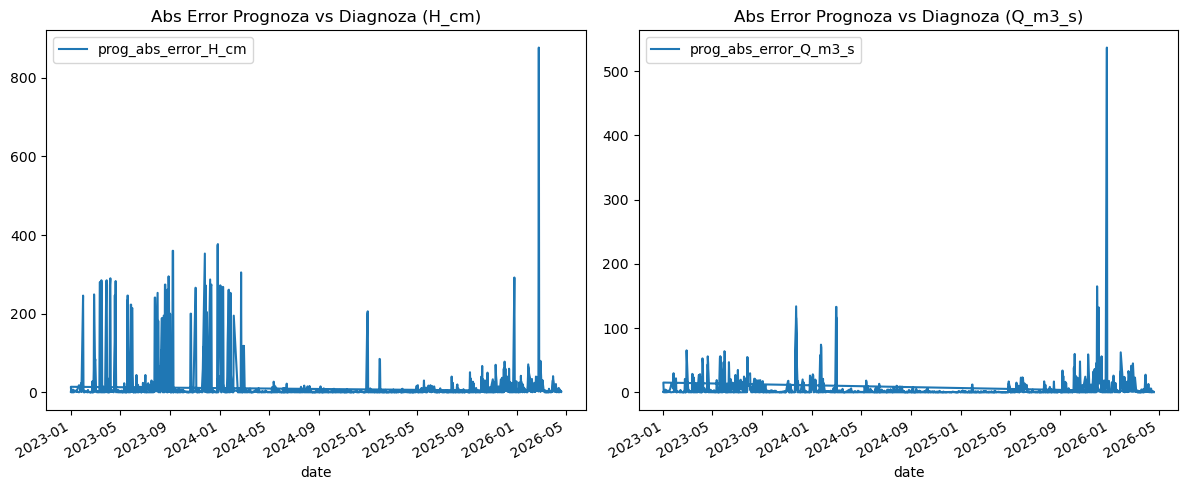

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
main_data[["date", "prog_abs_error_H_cm"]].plot.line(x="date", y="prog_abs_error_H_cm", ax=ax[0], title="Abs Error Prognoza vs Diagnoza (H_cm)")
main_data[["date", "prog_abs_error_Q_m3_s"]].plot.line(x="date", y="prog_abs_error_Q_m3_s", ax=ax[1], title="Abs Error Prognoza vs Diagnoza (Q_m3_s)")
plt.tight_layout()
plt.show()

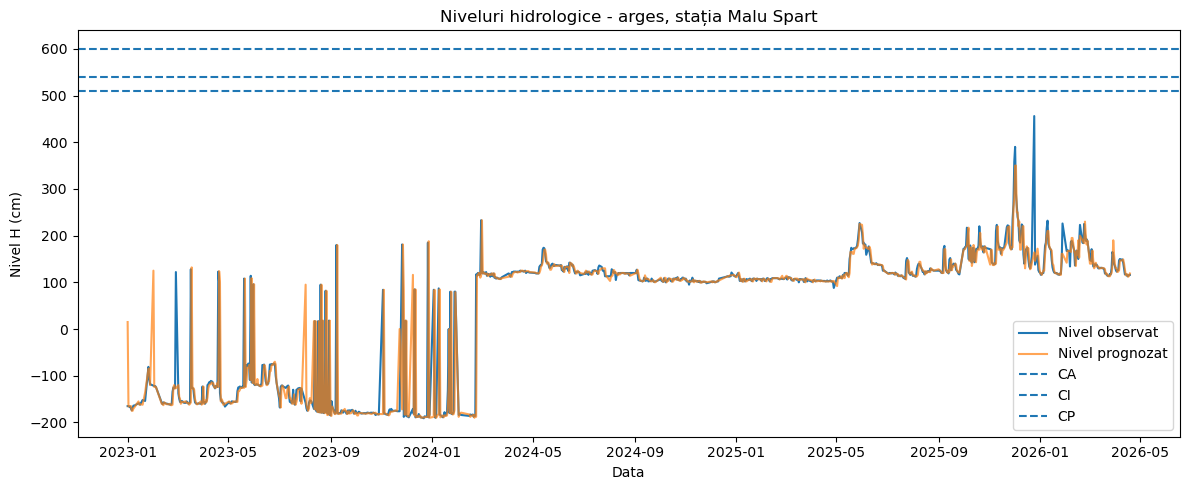

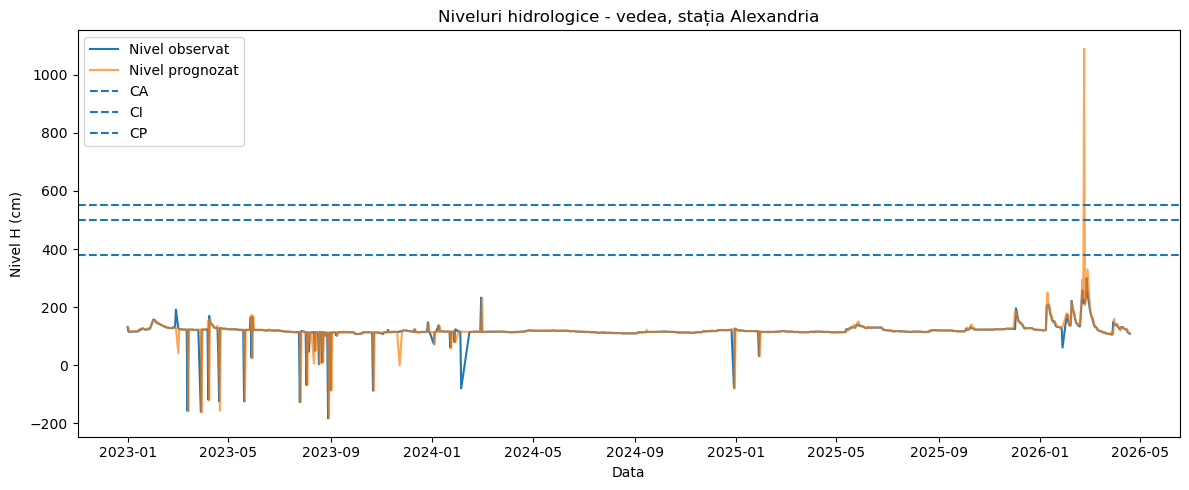

In [33]:

for (river, station), g in main_data.groupby(["raul_matched", "statia_matched"]):
    g = g.sort_values("date")

    plt.figure(figsize=(12, 5))
    plt.plot(g["date"], g["diag_H_cm"], label="Nivel observat")
    plt.plot(g["date"], g["prog_H_cm"], label="Nivel prognozat", alpha=0.7)

    ca = g["CA_cm"].median()
    ci = g["CI_cm"].median()
    cp = g["CP_cm"].median()

    plt.axhline(ca, linestyle="--", label="CA")
    plt.axhline(ci, linestyle="--", label="CI")
    plt.axhline(cp, linestyle="--", label="CP")

    plt.title(f"Niveluri hidrologice - {river}, stația {station}")
    plt.xlabel("Data")
    plt.ylabel("Nivel H (cm)")
    plt.legend()
    plt.tight_layout()
    plt.show()